# College Board Interview Project
# Analysis of GDP/College Enrollment Relationship
### Jason M. Cherry
### 2026-05-10

## Overview
In this analysis, the client has asked to understand how GDP is related to university (post-secondary) enrollment. For this analysis I decided to approach this as a question about how a change in GDP levels translates to a change in enrollment levels. As such I will be examining how the trends of the two values correlate with each other, rather than how the raw values correlate.

At the bottom of this notebook is an additional analysis on civil/geopolitical event identification, as required by the project.

To use this repo it is strongly recommended to use uv to handle venv and package installation. The project can be initialized through a simple `uv install` call from the root of the repo. The python environment for the notebooks should be run through that environment. I recommend using PyCharm for this.

AI Disclaimer: AI (Claude) was used to identify tooling approaches and code structure, as well as support the writing of documentation. The analysis and code are 100% human-authored.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns

Below are custom functions that support data processing, model construction, and visualization.

In [2]:
from tools import (geoplot_vals, load_enroll_data, load_gdp_data,
                   model_trends, parse_country_data, sum_enroll_data)

Data is loaded below.

In [3]:
data_path = Path('./data')

gdp_file = data_path / 'Countries GDP 1960-2020.csv'
enroll_file = data_path / 'enrollments.csv'

In [4]:
gdp_data = load_gdp_data(gdp_file)
enroll_data = load_enroll_data(enroll_file)

## Aligning the two datasets

Not all countries show up in both datasets, and some have gaps across the years. `parse_country_data` builds a list of every country and flags the ones with complete data in both sources. Only those countries are used in the rest of the analysis.

In [5]:
country_codes = parse_country_data(gdp_data, enroll_data)

## Aggregating enrollment to country totals

The enrollment data has multiple rows per country per year, broken out by institution type and level. The GDP data is one row per country per year. To line them up I sum enrollment on `students5_estimated` to get a single total per country per year.

In [6]:
enroll_sum = sum_enroll_data(enroll_data, 'students5_estimated')

## Modeling growth trends per country

For each country, `model_trends` fits a smoothing model to the GDP series and the enrollment series, and pulls out the trend at each year. The result is a pair of growth trends per country, one for GDP and one for enrollment.

The reason for using trends instead of raw values: any two series that grow over time will look correlated even when they have nothing to do with each other. Looking at trends instead tells me whether the two are speeding up and slowing down together, which is the actual question I want to answer.

In [7]:
active_country_codes = country_codes.loc[country_codes['full_avail']]
trends = model_trends(active_country_codes, gdp_data, enroll_sum)

## Per country trend correlation

For each country, I take the correlation between its GDP trend and its enrollment trend. That gives one number per country. A positive value means GDP and enrollment grow in sync, a negative value means they move opposite, and a value near zero means the two are not really linked.

In [8]:
trend_corr = pd.Series({
    country_code: country_trend.dropna().corr().iloc[0,1]
    for country_code, country_trend in trends.items()
}, name='trend_corr')

## Distribution of trend coupling across countries

The histogram shows how those correlations are distributed across countries. If most countries show a positive value, GDP growth is a reliable predictor of enrollment growth. If they cluster around zero, the two are mostly unrelated. A wide spread means the relationship is real but depends on the country.

<Axes: xlabel='trend_corr', ylabel='Count'>

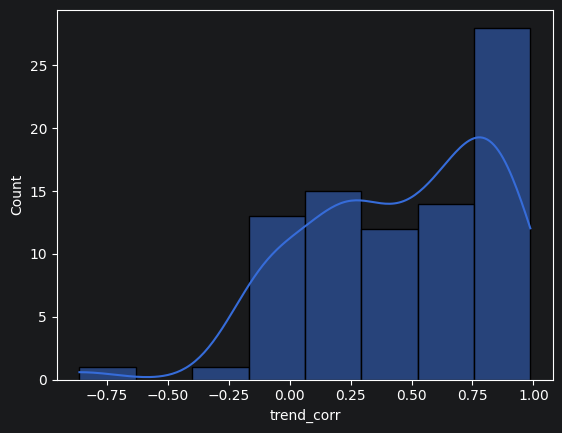

In [9]:
sns.histplot(trend_corr, kde=True)

## Geographic distribution

Plotting the same correlations on a world map shows whether there's any regional pattern. Groups of countries with similar values may share economic or institutional traits that affect the relationship.

In [10]:
geoplot_vals(trend_corr.reset_index(), loc_col='index', val_col='trend_corr')

## Does private versus public composition matter?

It's worth checking whether the strength of the GDP/enrollment link depends on how privatized a country's education system is. To do this I take each country's average private institution ratio and correlate it with the country's trend correlation from above. A non-zero result means privatization plays a role in how GDP and enrollment move together.

In [11]:
private_ratio = enroll_data.groupby(['countrycode', 'year'])['private01'].mean().reset_index()
private_ratio['year'] = private_ratio['year'].astype(int)
private_growth_corr = pd.concat([trend_corr, private_ratio.groupby('countrycode')['private01'].mean()], axis=1).dropna().corr().iloc[0,1]
private_growth_corr

np.float64(0.13861860871782306)

## Does country wealth level matter?

Same approach, but with country wealth instead of privatization. Do richer countries (higher mean GDP across the period) show a stronger or weaker GDP/enrollment link than poorer ones? A positive correlation here means wealth strengthens the link, a negative one means it weakens it, and a value near zero means wealth doesn't matter.

In [12]:
gdp_growth_corr = pd.concat([trend_corr, gdp_data.mean(axis=1).rename('mean_gdp')], axis=1).dropna().corr().iloc[0,1]
gdp_growth_corr

np.float64(-0.3274041113011594)

## Conclusions

In general there's a positive correlation between rising GDP and rising university enrollment. There does seem to be a controlling factor in nation wealth however, as wealthier countries are less likely to see a positive relationship here (with the USA being the standout example). The presence of private institutions seems to increase the positive correlation here as well, however to a lesser degree than wealth.

## Limitations
Only matching time slices were used in this analysis, limiting the analysis to same-year correlation. This analysis did not examine multi-year lagged impacts of GDP on enrollment or vice versa, and this would be the logical next-step for this work. Additionally, confidence intervals were not calculated for this analysis, and would be critical for any published/production-grade work. Finally, the analysis treated all countries with equal weight, but this is likely not valid for any given use-case of this analysis. This analysis should be re-examined and re-conducted with a tighter objective in mind to best support client needs.

# Civil/Geopolitical Event Analysis

The core question here: can a spike in closed universities serve as a leading indicator of GDP decline? If university closures tend to happen ahead of broader economic decline, the count of closures in one year should be associated with the GDP trend in the year that follows.

To test this I correlate the number of universities closed in a given year with the GDP trend of the following year, on a per country basis. The 1-year lag is what makes this a leading indicator check rather than a same-year correlation. Only countries with at least 1 closed university (and available GDP data) are included.

In [13]:
closed_unis = enroll_data[['countrycode', 'iau_id1', 'yrclosed']].drop_duplicates()
closed_unis = closed_unis.loc[closed_unis['yrclosed'].notnull()]
closed_unis['yrclosed'] = closed_unis['yrclosed'].astype(int)

In [14]:
country_gdp_closed_shift = {}
for country_code, trend_data in trends.items():
    if not country_code in closed_unis['countrycode'].unique():
        continue

    gdp_data = trend_data['gdp'].dropna()
    closed_data = closed_unis.loc[closed_unis['countrycode'] == country_code].groupby('yrclosed').size().rename('closed')

    closed_gdp_data = pd.concat([closed_data, gdp_data], axis=1).fillna(0).sort_index()

    closed_gdp_shift = closed_gdp_data.copy()
    closed_gdp_shift['gdp'] = closed_gdp_shift['gdp'].shift(-1)

    country_gdp_closed_shift[country_code] = closed_gdp_shift.corr().iloc[0,1]

country_gdp_closed_shift = pd.Series(country_gdp_closed_shift, name='closed_gdp_lead')

## Mean of correlation

A quick note on sign: a positive value means years with more university closures are followed by years of rising GDP. A negative value would be consistent with the leading indicator idea, where closures show up before GDP decline. The mean below summarizes those values across all the countries included.

In [15]:
country_gdp_closed_shift.mean()

np.float64(0.030645788297905256)

## Distribution of the lagged correlation

The histogram shows how the closure-to-GDP correlations are distributed across countries. A peak below zero would support the leading indicator idea. A peak near zero means there's no consistent relationship across the sample.

<Axes: xlabel='closed_gdp_lead', ylabel='Count'>

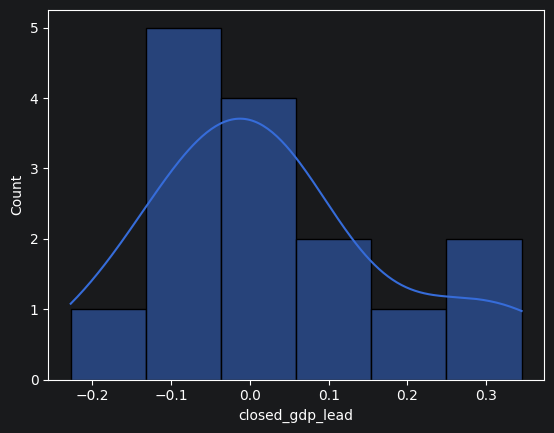

In [16]:
sns.histplot(country_gdp_closed_shift, kde=True)

## Geographic distribution

And the same correlations on a world map, in case the relationship shows a regional pattern instead of a global one.

In [17]:
geoplot_vals(country_gdp_closed_shift.reset_index(), loc_col='index', val_col='closed_gdp_lead')

## Results

The mean correlation across countries comes out essentially at zero, and the histogram shows a roughly symmetric distribution centered on zero. A handful of countries do show meaningful positive or negative correlations, but there's no consistent direction across the sample.

So at a 1-year lag, university closures don't look like a useful leading indicator of GDP changes. Whatever signal exists is country-specific rather than global, and would need to be investigated on a per country basis to be actionable.

Mind you, only 15 countries had enough data to be included, so this may not be representative.